# 전력 예측 오차 원인 분석 (LSTM 예측 vs 실제)

다변량 LSTM의 예측 오차를 **허용(±10% 이내) / 중간 / 큰 × 과소 / 과대** 그룹으로 나누고 (전체 시간 + peak 시간 각각),
어떤 조건(시각 · 날씨 · 생산 · 인원 등)에서 큰 오차가 나는지 찾는다. 결과는 `LSTM_AIModel_Enhanced.py`의 입력 변수 설계에 반영했다.

- **입력**: `full_df_power_only*.pkl` (`Make_full_power_pkl.ipynb` 출력)
- **출력**: `Error_Driver_Pipeline_결과.xlsx`

**부호 규칙**
- `err = 실제 − 예측`, `오차율 = err / 실제 × 100`
- **양수 = 과소예측** (실제가 더 큼), 음수 = 과대예측

**분석 순서**

| 절 | 내용 |
|---|---|
| 1 | 오차 · 그룹 · 설명 변수 만들기 |
| 2 | 그룹 분포 |
| 3 | 시각(하루 패턴)별 오차 |
| 4 | 변수 구간별 오차 비율 |
| 5 | 시각을 통제한 변수 비교 |
| 6 | 분류 모델 + 요인별 영향력 |
| 7 | 보조 분석 (급증 태그 · 전기요금 구간) |
| 8 | 엑셀 저장 |

**이전 분석(v4) 대비 변수 처리 기준**

| 변수 | 처리 | 이유 |
|---|---|---|
| 생산량 · 기온 · 풍속 · 습도 · 강수량 · 공장인원 | 채택 (수준값 + 변화량 + rolling) | 입력 조건으로 타당 |
| 변화율(%) | **로그 변화량 · 절대 변화량으로 교체** | 직전 값이 0 근처면 수백~수천 %로 폭주해 평균이 왜곡됨 |
| 기온 절대 변화량(℃) | 채택 (1시간, 3시간) | v4 보조 분석과 동일 |
| 근무일 / 비근무일 | 채택 (`workday`, `is_weekend`, `is_holiday`) | 일정이 다르면 부하 패턴이 다름 |
| 전기요금(계절) | 모델에서 제외, 분포표만 | 값이 3개뿐이라 사실상 시기 라벨(계절 대리변수) |
| 실제 전력 급증(20%↑) | 모델에서 제외, 상황 태그 분포만 | 오차와 같은 시점의 결과값이라 원인이 아님 → 직전 값(lag)으로 대체 |
| 전력 구간합계 / 최대 / 최소 / 변동폭 | 제외 | 실제 전력에서 파생된 값 (정보 누수) |
| 월(`m`), `day` | 제외 | 시기 라벨이라 주 단위 교차검증에서 일반화 불가 → 시각 · 요일로 대체 |
| 분석 대상 오차 | 과대예측만 → **과소 · 과대 모두** | 두 방향 오차를 모두 확인 |

## 0. 설정 · 데이터 불러오기

In [1]:
import os, glob, warnings
import numpy as np, pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score
warnings.filterwarnings("ignore")

# ------------------------- 파라미터 -------------------------
TOL_PCT     = 10     # 허용 오차 (±%)
BIG_PCT     = 20     # 큰 오차 기준 (%): 10~20 중간, 20 초과 큰
MIN_KW      = 8      # 오차율이 10% 넘어도 절대오차가 이 값(kW) 미만이면 '허용' (저전력 시간 착시 방지)
OUTLIER_PCT = None   # 예: 60 → 오차율 60% 이상 행 제외 (v4 방식). None = 제외 안 함
PEAK_Q      = 0.90   # peak = 실제 전력이 전체 기간 상위 (1-PEAK_Q) 이상인 시간
USE_SPLIT   = "all"  # "all": 전체 / "test": 테스트 구간만 (train은 in-sample이라 오차가 작게 나옴)
N_FOLDS     = 5      # 주 단위 블록 교차검증 fold 수
MIN_BIN     = 30     # 구간별 표에서 표본이 이보다 적으면 비율을 NaN 처리
MIN_POS     = 40     # 모델링에 필요한 최소 양성(오차 그룹) 수
SHOW_ALL_IMP = False # True면 '해석 가능'이 아닌 모델의 중요도도 출력

# ------------------------- 한글 폰트 -------------------------
cands = ["Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR", "AppleGothic", "NanumBarunGothic", "UnDotum"]
names = {f.name for f in font_manager.fontManager.ttflist}
font = next((f for f in cands if f in names), None)
if font: mpl.rcParams["font.family"] = font
else: print("한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다 (NanumGothic 등 설치 권장).")
mpl.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 200)

# ------------------------- 데이터 -------------------------
files = sorted(glob.glob("full_df_power_only*.pkl"))
if not files: raise FileNotFoundError("full_df_power_only*.pkl 을 노트북과 같은 폴더에 두세요 (pyarrow 필요).")
PKL_PATH = files[0]
d = pd.read_pickle(PKL_PATH)
d["datetime"] = pd.to_datetime(d["datetime"])
d = d.sort_values("datetime").reset_index(drop=True)
for c in ["power_true","power_pred","기온","풍속","습도","강수량","공장인원","생산량","is_weekend","is_holiday","전기요금(계절)"]:
    d[c] = pd.to_numeric(d[c], errors="coerce")
d["test"] = d["split"].astype(str).str.startswith("test")
gap = d["datetime"].diff().dt.total_seconds().div(3600).dropna()
print(f"파일: {PKL_PATH} | 행 {len(d):,} | 기간 {d.datetime.min():%Y-%m-%d} ~ {d.datetime.max():%Y-%m-%d} | 1시간 간격이 아닌 곳 {(gap != 1).sum()}곳")
print("test 구간:", f"{d[d.test].datetime.min():%Y-%m-%d} ~ {d[d.test].datetime.max():%Y-%m-%d}", "| train은 in-sample 예측")

/home/kampuser/.local/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/kampuser/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.4.0' currently installed).
  from pandas.core import (


파일: full_df_power_only.pkl | 행 6,144 | 기간 2021-01-02 ~ 2021-09-14 | 1시간 간격이 아닌 곳 0곳
test 구간: 2021-07-25 ~ 2021-09-14 | train은 in-sample 예측


## 1. 오차 · 그룹 · 설명 변수 만들기
- **그룹**: `0_허용`(±10% 이내 또는 절대오차 < `MIN_KW`) / `중간과소` · `큰과소`(실제가 더 큼) / `중간과대` · `큰과대`(예측이 더 큼)
- 모든 "직전" 값은 **시간 간격을 확인하며 과거 값만** 사용한다 (현재 시점의 실제 전력은 설명 변수로 쓰지 않음).
- **평소 패턴**(`usual_load`)은 같은 시각 · 같은 근무유형의 *이전 날들* 평균 전력이다.

In [2]:
def lag(s, k=1):
    """k시간 전 값. 시간 간격이 정확히 k시간인 행만 유효."""
    ok = (d["datetime"] - d["datetime"].shift(k)).dt.total_seconds().div(3600) == k
    return s.shift(k).where(ok)

# ---- 오차와 그룹 ----
d["err_kw"]  = d["power_true"] - d["power_pred"]
d["err_pct"] = d["err_kw"] / d["power_true"].where(d["power_true"] > 0) * 100      # +: 과소, -: 과대
GROUPS = ["0_허용", "중간과소", "큰과소", "중간과대", "큰과대"]
def make_group(pct, kw):
    if np.isnan(pct): return np.nan
    a = abs(pct)
    if a <= TOL_PCT or abs(kw) < MIN_KW: return "0_허용"
    return ("큰" if a > BIG_PCT else "중간") + ("과소" if pct > 0 else "과대")
d["grp"] = [make_group(p, k) for p, k in zip(d["err_pct"], d["err_kw"])]

# ---- 일정 (하루 패턴) ----
d["hour"] = d["datetime"].dt.hour; d["dow"] = d["datetime"].dt.dayofweek
d["sin_h"] = np.sin(2*np.pi*d["hour"]/24); d["cos_h"] = np.cos(2*np.pi*d["hour"]/24)
d["workday"]  = ((d["is_weekend"] == 0) & (d["is_holiday"] == 0)).astype(int)
d["day_type"] = np.where(d["workday"] == 1, "근무일", "비근무일")
run, c = [], 0
for v in d["생산량"]:
    c = c + 1 if v > 0 else 0; run.append(c)
d["run_hours"] = run                                  # 생산 연속 가동 시간 (1 = 기동 첫 시간)

# ---- 평소 패턴 (같은 시각·근무유형의 이전 날 평균, 과거만) ----
d["usual_load"]  = d.groupby(["day_type","hour"])["power_true"].transform(lambda s: s.shift(1).expanding(5).mean())
d["usual_delta"] = d["usual_load"] - lag(d["usual_load"], 1)             # 평소에도 이 시각에 전력이 변하는 정도(기동·전환 시점)
d["dev_prev"]    = lag(d["power_true"], 1) - lag(d["usual_load"], 1)     # 직전 시간이 평소보다 얼마나 달랐나

# ---- 직전 상태 (예측 시점에 이미 알 수 있는 값) ----
d["p_lag1"]  = lag(d["power_true"], 1)
d["lag_pct"] = lag(d["err_pct"], 1).clip(-100, 100)
d["lag_kw"]  = lag(d["err_kw"], 1)

# ---- 날씨: 수준 + 변화량 + rolling ----
d["d_temp1"] = d["기온"] - lag(d["기온"], 1); d["d_temp3"] = d["기온"] - lag(d["기온"], 3)
d["d_wind"]  = (d["풍속"] - lag(d["풍속"], 1)).abs()
d["d_hum"]   = d["습도"] - lag(d["습도"], 1); d["d_rain"] = d["강수량"] - lag(d["강수량"], 1)
d["temp_r3"] = d["기온"].rolling(3, min_periods=1).mean()
d["temp_r24"] = d["기온"].rolling(24, min_periods=6).mean()              # 더위 누적(냉방 부하)

# ---- 생산·인원: 수준 + 로그 변화량 + rolling ----
d["d_prod_log"]  = np.log1p(d["생산량"]) - np.log1p(lag(d["생산량"], 1))
d["d_staff_log"] = np.log1p(d["공장인원"]) - np.log1p(lag(d["공장인원"], 1))
d["prod_r3"] = d["생산량"].rolling(3, min_periods=1).mean()
d["prod_vs_prev3"] = d["생산량"] - lag(d["생산량"], 1).rolling(3, min_periods=1).mean()

# ---- 변수 묶음 / 단계별 변수 집합 (S1 ⊂ S2 ⊂ S3) ----
FEATURE_GROUPS = {
    "일정(시각·요일)": ["hour","sin_h","cos_h","dow","is_weekend","is_holiday"],
    "날씨":          ["기온","풍속","습도","강수량","d_temp1","d_temp3","d_wind","d_hum","d_rain","temp_r3","temp_r24"],
    "생산·인원":      ["생산량","공장인원","d_prod_log","d_staff_log","prod_r3","prod_vs_prev3","run_hours"],
    "평소 패턴":      ["usual_load","usual_delta"],
    "직전 상태":      ["p_lag1","dev_prev","lag_pct","lag_kw"],
}
S1 = FEATURE_GROUPS["일정(시각·요일)"]
S2 = S1 + FEATURE_GROUPS["날씨"] + FEATURE_GROUPS["생산·인원"]
S3 = S2 + FEATURE_GROUPS["평소 패턴"] + FEATURE_GROUPS["직전 상태"]

# ---- 분석 대상 (전력 > 0 인 시간) ----
A = d[d["grp"].notna()].copy()
if OUTLIER_PCT: A = A[A["err_pct"].abs() < OUTLIER_PCT]
if USE_SPLIT == "test": A = A[A["test"]]
peak_th = d["power_true"].quantile(PEAK_Q)
A["peak"] = A["power_true"] >= peak_th
A["week"] = ((A["datetime"].dt.normalize() - d["datetime"].min().normalize()).dt.days // 7)
print(f"분석 대상 {len(A):,}행 (USE_SPLIT={USE_SPLIT}) | peak 기준 {peak_th:.0f}kW 이상 {A.peak.sum()}행")

분석 대상 6,127행 (USE_SPLIT=all) | peak 기준 169kW 이상 643행


## 2. 그룹 분포

In [3]:
def dist(df, by):
    t = pd.crosstab(df[by], df["grp"]).reindex(columns=GROUPS, fill_value=0)
    return pd.concat([t, (t.div(t.sum(1), axis=0) * 100).round(1).add_suffix("(%)")], axis=1)

print("[전체]"); print((A["grp"].value_counts().reindex(GROUPS).to_frame("행 수").assign(**{"비율(%)": lambda x: (x["행 수"]/x["행 수"].sum()*100).round(1)})).to_string())
print("\n[학습/예측 구간별] ← train은 in-sample이라 허용 비율이 높게 나옴"); print(dist(A.assign(구간=np.where(A.test, "test", "train")), "구간").to_string())
print("\n[근무일/비근무일]"); print(dist(A, "day_type").to_string())
print(f"\n[peak 시간 (실제 ≥ {peak_th:.0f}kW)]  ※ peak를 실제값으로 고르면 과대예측이 구조적으로 거의 없음 (선택편향)")
print(dist(A.assign(구분=np.where(A.peak, "peak", "비peak")), "구분").to_string())

[전체]
       행 수  비율(%)
grp              
0_허용  5000   81.6
중간과소   736   12.0
큰과소    164    2.7
중간과대   113    1.8
큰과대    114    1.9

[학습/예측 구간별] ← train은 in-sample이라 허용 비율이 높게 나옴
grp    0_허용  중간과소  큰과소  중간과대  큰과대  0_허용(%)  중간과소(%)  큰과소(%)  중간과대(%)  큰과대(%)
구간                                                                          
test    911   213   39    34   20     74.9     17.5     3.2      2.8     1.6
train  4089   523  125    79   94     83.3     10.7     2.5      1.6     1.9

[근무일/비근무일]
grp       0_허용  중간과소  큰과소  중간과대  큰과대  0_허용(%)  중간과소(%)  큰과소(%)  중간과대(%)  큰과대(%)
day_type                                                                       
근무일       3322   654   84    92   72     78.6     15.5     2.0      2.2     1.7
비근무일      1678    82   80    21   42     88.2      4.3     4.2      1.1     2.2

[peak 시간 (실제 ≥ 169kW)]  ※ peak를 실제값으로 고르면 과대예측이 구조적으로 거의 없음 (선택편향)
grp    0_허용  중간과소  큰과소  중간과대  큰과대  0_허용(%)  중간과소(%)  큰과소(%)  중간과대(%)  큰과대(%)
구분                                   

## 3. 시각(하루 패턴)별 오차
"원래 이 시간대에 오차가 많이 나는가"를 확인한다. `sin/cos`는 모델 입력용 표현이고, 사람이 볼 때는 **시각별 비율**이 가장 직관적이다.

         표본  과소(%)  큰과소(%)  과대(%)  큰과대(%)  평균오차(kW)  평균 실제전력(kW)
hour                                                            
0     255.0   19.2    11.8   20.8    12.5      -0.4         52.9
1     255.0    3.9     0.4   11.8     7.5      -1.0         77.0
2     255.0    2.4     0.4    1.6     0.4      -0.7         79.4
3     255.0    3.5     0.8    0.8     0.0       1.6         77.3
4     255.0    6.7     0.4    2.4     0.4       2.9         78.6
5     255.0    1.2     0.4    7.1     1.6      -2.4         68.2
6     255.0   20.4     2.4    1.2     0.8       4.8         79.2
7     255.0   27.8    16.5    7.5     5.5       6.4         88.2
8     255.0   22.0     4.7    1.6     1.2       9.0        122.1
9     255.0   17.3     1.6    2.0     2.0       6.8        119.9
10    255.0   15.7     1.6    1.6     1.2       6.1        115.6
11    256.0   22.7     3.9    0.8     0.8      10.1        120.9
12    256.0    3.5     1.2   10.9     2.3      -1.5         77.6
13    256.0   17.2     1.

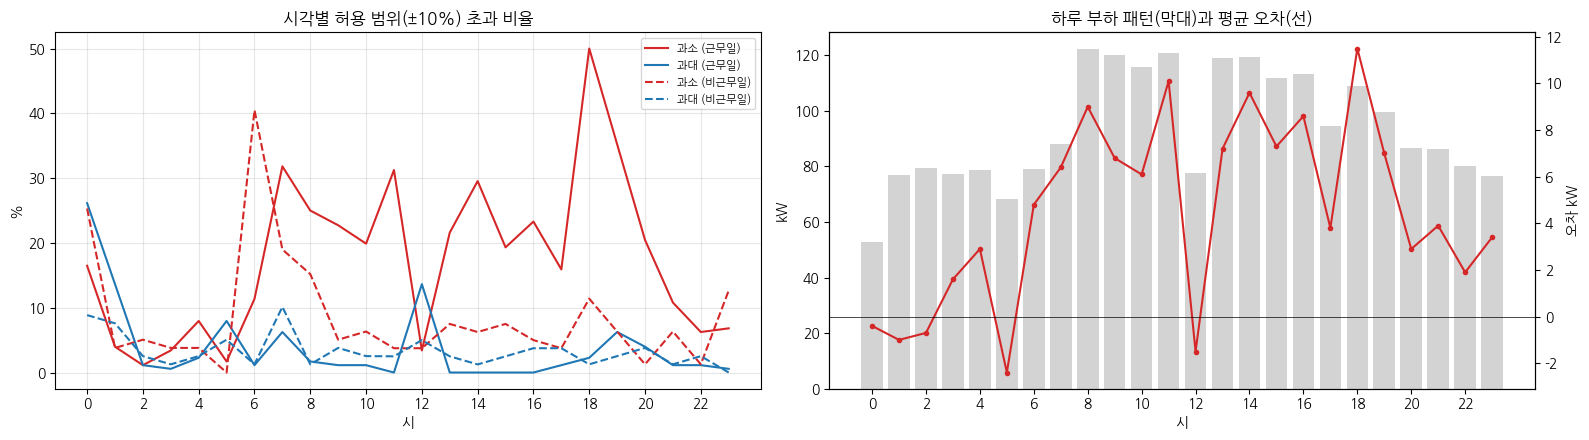

In [4]:
HOUR_TBL = A.groupby("hour").apply(lambda x: pd.Series({
    "표본": len(x),
    "과소(%)": x.grp.isin(["중간과소","큰과소"]).mean()*100, "큰과소(%)": (x.grp == "큰과소").mean()*100,
    "과대(%)": x.grp.isin(["중간과대","큰과대"]).mean()*100, "큰과대(%)": (x.grp == "큰과대").mean()*100,
    "평균오차(kW)": x.err_kw.mean(), "평균 실제전력(kW)": x.power_true.mean()})).round(1)
print(HOUR_TBL.to_string())

fig, ax = plt.subplots(1, 2, figsize=(16, 4.5))
for dt, ls in [("근무일","-"), ("비근무일","--")]:
    s = A[A.day_type == dt].groupby("hour")
    ax[0].plot(s.apply(lambda x: x.grp.isin(["중간과소","큰과소"]).mean()*100), ls, color="tab:red",  label=f"과소 ({dt})")
    ax[0].plot(s.apply(lambda x: x.grp.isin(["중간과대","큰과대"]).mean()*100), ls, color="tab:blue", label=f"과대 ({dt})")
ax[0].set(title="시각별 허용 범위(±10%) 초과 비율", xlabel="시", ylabel="%"); ax[0].set_xticks(range(0, 24, 2)); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].bar(HOUR_TBL.index, HOUR_TBL["평균 실제전력(kW)"], color="lightgray", label="평균 실제전력")
ax2 = ax[1].twinx(); ax2.plot(HOUR_TBL.index, HOUR_TBL["평균오차(kW)"], color="tab:red", marker="o", ms=3, label="평균오차(+과소)"); ax2.axhline(0, color="k", lw=.5)
ax[1].set(title="하루 부하 패턴(막대)과 평균 오차(선)", xlabel="시", ylabel="kW"); ax[1].set_xticks(range(0, 24, 2)); ax2.set_ylabel("오차 kW")
plt.tight_layout(); plt.show()

## 4. 변수 구간별 오차 비율
- 표본이 `MIN_BIN`보다 적은 칸은 NaN으로 표시한다. **표본 열을 먼저 확인**할 것.
- 인접한 시간은 서로 비슷하므로, 표본 수만큼 독립적인 증거는 아니다.

In [5]:
def zero_q(s, q=4):
    """0인 시간을 별도 구간으로 두고, 0보다 큰 값을 q분위로 나눈다 (0이 많은 변수용)."""
    pos = s[s > 0]; qc = pd.qcut(pos, q, duplicates="drop")
    cats = ["0(비가동)"] + [str(i) for i in qc.cat.categories]
    out = pd.Series("0(비가동)", index=s.index, dtype=object); out.loc[pos.index] = qc.astype(str).values
    return pd.Categorical(out, categories=cats, ordered=True)

def rate_table(df, col, bins=None, labels=None, q=None, zq=None):
    if zq: g = zero_q(df[col], zq)
    else: g = pd.qcut(df[col], q, duplicates="drop") if q else pd.cut(df[col], bins, labels=labels, right=False)
    def f(x):
        n = len(x); ok = n >= MIN_BIN
        r = lambda m: (m.mean()*100) if ok else np.nan
        return pd.Series({"표본": n, "과소(%)": r(x.grp.isin(["중간과소","큰과소"])), "큰과소(%)": r(x.grp == "큰과소"),
                          "과대(%)": r(x.grp.isin(["중간과대","큰과대"])), "큰과대(%)": r(x.grp == "큰과대")})
    return df.groupby(g, observed=True).apply(f).round(1)

SPEC = {"생산량(0 별도 + 4분위)": ("생산량", dict(zq=4)), "공장인원(0 별도 + 4분위)": ("공장인원", dict(zq=4)),
        "기온(℃)": ("기온", dict(bins=[-99,5,15,25,28,99], labels=["<5","5~15","15~25","25~28","≥28"])),
        "기온 24h 평균(5분위)": ("temp_r24", dict(q=5)),
        "풍속(5분위)": ("풍속", dict(q=5)), "습도(%)": ("습도", dict(bins=[0,40,60,80,101], labels=["<40","40~60","60~80","≥80"])),
        "기온 3h 변화(℃)": ("d_temp3", dict(bins=[-99,-2,-.5,.5,2,99], labels=["≤-2","-2~-.5","유지","+.5~+2","≥+2"])),
        "생산량 로그변화(직전 대비)": ("d_prod_log", dict(bins=[-99,-1,-.2,.2,1,99], labels=["큰 감소","감소","유지","증가","큰 증가"])),
        "기동 후 경과(h)": ("run_hours", dict(bins=[0,1,2,3,5,9,9999], labels=["0(비가동)","1(기동)","2","3~4","5~8","9+"]))}
BIN_TABLES = {nm: rate_table(A, col, **kw) for nm, (col, kw) in SPEC.items()}
BIN_TABLES["비(강수>0)"] = A.groupby(A["강수량"].gt(0).map({False:"비 없음", True:"비 있음"})).apply(
    lambda x: pd.Series({"표본": len(x), "과소(%)": x.grp.isin(["중간과소","큰과소"]).mean()*100, "큰과소(%)": (x.grp=="큰과소").mean()*100,
                         "과대(%)": x.grp.isin(["중간과대","큰과대"]).mean()*100, "큰과대(%)": (x.grp=="큰과대").mean()*100})).round(1)
for nm, t in BIN_TABLES.items(): print(f"\n=== {nm} ==="); print(t.to_string())

# 기온 × 생산량 교차표 (큰 과소예측 비율)
A["prod_t"] = pd.qcut(A["생산량"].where(A["생산량"] > 0), 3, labels=["생산 낮음","생산 중간","생산 높음"])
A["temp_b"] = pd.cut(A["기온"], [-99,25,28,99], labels=["<25℃","25~28℃","≥28℃"], right=False)
CROSS = A.dropna(subset=["prod_t"]).groupby(["prod_t","temp_b"], observed=True).apply(lambda x: (x.grp.isin(["큰과소"]).mean()*100) if len(x) >= MIN_BIN else np.nan).unstack().round(1)
print("\n=== 기온 x 생산량 (생산>0 시간): 큰 과소예측 비율(%) ==="); print(CROSS.to_string())


=== 생산량(0 별도 + 4분위) ===
                      표본  과소(%)  큰과소(%)  과대(%)  큰과대(%)
0(비가동)            2616.0    7.3     4.0    4.1     3.1
(0.999, 116.0]     879.0   10.4     1.3    5.3     1.4
(116.0, 498.0]     881.0   13.4     1.6    4.5     0.9
(498.0, 1175.0]    874.0   24.4     2.1    1.8     0.8
(1175.0, 9830.0]   877.0   32.6     1.8    1.8     0.8

=== 공장인원(0 별도 + 4분위) ===
                      표본  과소(%)  큰과소(%)  과대(%)  큰과대(%)
0(비가동)            2616.0    7.3     4.0    4.1     3.1
(0.00089, 0.278]   878.0   10.7     1.3    4.8     1.1
(0.278, 0.96]      878.0   16.7     1.3    4.0     0.5
(0.96, 1.974]      877.0   26.2     1.9    1.1     0.3
(1.974, 48.386]    878.0   27.0     2.3    3.6     1.9

=== 기온(℃) ===
           표본  과소(%)  큰과소(%)  과대(%)  큰과대(%)
기온                                         
<5      826.0   14.0     4.6    5.7     4.6
5~15   1758.0   11.1     2.3    3.0     1.5
15~25  2591.0   13.1     1.7    3.5     1.0
25~28   594.0   22.6     4.2    4.5     2.5
≥28     35

## 5. 시각을 통제한 변수 비교
오차 그룹은 특정 시각에 몰려 있어서, 그룹끼리 변수 평균을 그냥 비교하면 **시각 차이가 변수 차이처럼 보인다.** (v4의 Baseline 비교를 보완)

- 각 변수에서 **같은 시각 · 근무유형의 평균을 뺀 뒤**, `0_허용` 대비 표준화 차이(= 차이 ÷ 허용 그룹의 표준편차)를 본다.
- 절댓값 **0.2 이상**이면 의미 있는 차이로 본다.
- 표 위쪽(생산량 ~ run_hours)은 **원인 후보**, 아래쪽(usual_load, usual_delta, p_lag1, dev_prev, lag_pct)은 평소 패턴 · 직전 상태라서 **지속성** 정보다.
- 표본이 적은 그룹(특히 peak의 n=35)은 부호와 크기를 참고만 한다.

[전체] 시각 통제 후 허용 대비 표준화 차이
               중간과소 (n=736)  큰과소 (n=164)  중간과대 (n=113)  큰과대 (n=114)
생산량                    0.30        -0.10          0.01        -0.05
공장인원                  -0.01        -0.12          0.04         0.08
기온                     0.21        -0.03          0.33        -0.36
풍속                    -0.01         0.07         -0.26         0.17
습도                     0.23        -0.12          0.22        -0.33
강수량                    0.13        -0.09         -0.12        -0.09
d_temp1               -0.12        -0.07         -0.02         0.09
d_temp3               -0.13        -0.11         -0.03         0.10
d_wind                -0.01        -0.12          0.09         0.19
d_hum                  0.05         0.11          0.11        -0.08
d_prod_log            -0.01        -0.12         -0.03        -0.27
d_staff_log           -0.08        -0.22         -0.03         0.06
prod_r3                0.41        -0.07          0.17        -0.00
prod_vs_prev3         

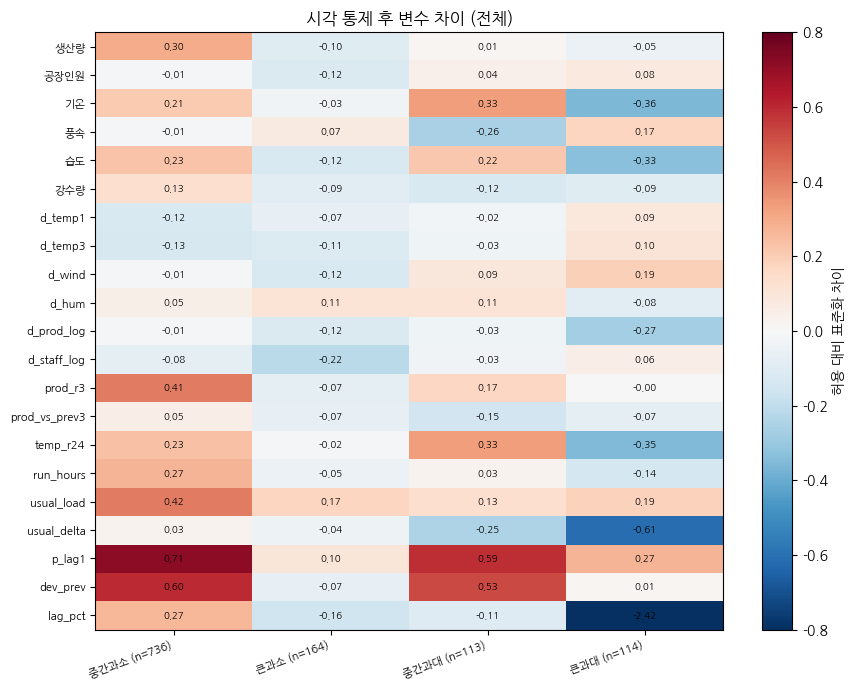


[peak]
               중간과소 (n=323)  큰과소 (n=35)  중간과대 (n=0)  큰과대 (n=0)
생산량                    0.05       -0.07         NaN        NaN
공장인원                  -0.00       -0.16         NaN        NaN
기온                     0.46        0.67         NaN        NaN
풍속                    -0.15       -0.07         NaN        NaN
습도                     0.23        0.23         NaN        NaN
강수량                    0.51        0.63         NaN        NaN
d_temp1               -0.16       -0.39         NaN        NaN
d_temp3               -0.10       -0.15         NaN        NaN
d_wind                -0.06       -0.08         NaN        NaN
d_hum                  0.13        0.30         NaN        NaN
d_prod_log            -0.18       -0.30         NaN        NaN
d_staff_log           -0.19       -0.21         NaN        NaN
prod_r3                0.31        0.00         NaN        NaN
prod_vs_prev3         -0.12       -0.10         NaN        NaN
temp_r24               0.47        0.69        

In [6]:
CMP_VARS = ["생산량","공장인원","기온","풍속","습도","강수량","d_temp1","d_temp3","d_wind","d_hum","d_prod_log","d_staff_log",
            "prod_r3","prod_vs_prev3","temp_r24","run_hours","usual_load","usual_delta","p_lag1","dev_prev","lag_pct"]
def hour_adjusted_effect(df):
    adj = df[CMP_VARS] - df.groupby(["day_type","hour"])[CMP_VARS].transform("mean")
    base = adj[df.grp == "0_허용"]
    rows = {}
    for g in GROUPS[1:]:
        m = adj[df.grp == g]
        rows[f"{g} (n={len(m)})"] = (m.mean() - base.mean()) / base.std() if len(m) >= MIN_BIN else pd.Series(np.nan, index=CMP_VARS)
    return pd.DataFrame(rows)
def draw_heat(t, title):
    fig, ax = plt.subplots(figsize=(9, 7)); im = ax.imshow(t.values, cmap="RdBu_r", vmin=-.8, vmax=.8, aspect="auto")
    ax.set_xticks(range(t.shape[1])); ax.set_xticklabels(t.columns, rotation=20, ha="right", fontsize=8); ax.set_yticks(range(t.shape[0])); ax.set_yticklabels(t.index, fontsize=8)
    for i in range(t.shape[0]):
        for j in range(t.shape[1]):
            v = t.values[i, j]
            if not np.isnan(v): ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)
    plt.colorbar(im, label="허용 대비 표준화 차이"); ax.set_title(title); plt.tight_layout(); plt.show()

EFFECT_ALL  = hour_adjusted_effect(A)
EFFECT_PEAK = hour_adjusted_effect(A[A.peak])
print("[전체] 시각 통제 후 허용 대비 표준화 차이"); print(EFFECT_ALL.round(2).to_string())
draw_heat(EFFECT_ALL, "시각 통제 후 변수 차이 (전체)")
print("\n[peak]"); print(EFFECT_PEAK.round(2).to_string())

## 6. 분류 모델 + 요인별 영향력
- 각 오차 그룹 vs `0_허용`을 가려내는 모델을 **주 단위 블록 교차검증**으로 평가한다.
- 변수를 3단계로 늘리며 성능 변화를 본다.
  - **S1**: 일정(시각 · 요일)
  - **S2**: S1 + 날씨 · 생산 · 인원
  - **S3**: S2 + 평소 패턴 · 직전 상태
- **원인 후보는 S2까지**다. S3의 직전 상태(직전 실제전력, 직전 오차)는 "오차가 연달아 난다 / 부하 수준이 높다"는 **지속성 정보**라서 원인이 아니라 보정에 쓰는 값이다. 판정과 핵심 순위는 S2 기준으로 보고, S3은 "직전 상태까지 알면 얼마나 더 맞히나"로만 본다.
- **영향력**: 변수 묶음(일정 / 날씨 / 생산·인원 / 평소 패턴 / 직전 상태)을 통째로 섞었을 때 ROC-AUC가 얼마나 떨어지는지(permutation). 서로 겹치는 변수(생산량 · 인원 등)가 있어도 묶음 단위로 비교할 수 있다.
- **판정 (S2 기준)**: 양성 수 · fold 수가 충분하고, ROC ≥ 0.65, PR-AUC ≥ `양성비율 + 0.5 × min(양성비율, 1 − 양성비율)` 일 때만 **해석 가능**. 그렇지 않으면 순위를 해석하지 않는다.

In [7]:
# 클래스 불균형 보정(class_weight)을 지원하지 않는 sklearn 버전이면 기본값으로 생성
def new_model():
    kw = dict(max_depth=3, learning_rate=0.05, max_iter=150, min_samples_leaf=20, early_stopping=False, random_state=0)
    try: return HistGradientBoostingClassifier(class_weight="balanced", **kw)
    except TypeError: return HistGradientBoostingClassifier(**kw)

# 변수(묶음)를 섞었을 때 ROC-AUC 감소량 = 영향력
def perm_drop(m, X, y, base, cols, rng, reps=5):
    out = []
    for _ in range(reps):
        Xp = X.copy(); Xp[cols] = X[cols].values[rng.permutation(len(X))]
        out.append(base - roc_auc_score(y, m.predict_proba(Xp)[:, 1]))
    return float(np.mean(out))

S2_GROUPS = {g: c for g, c in FEATURE_GROUPS.items() if g in ("일정(시각·요일)", "날씨", "생산·인원")}

# 한 오차 그룹(양성) vs 0_허용(음성) 분류 성능 · 영향력 계산
def evaluate(sub, pos_labels):
    sub = sub[sub.grp.isin(["0_허용"] + pos_labels)]
    y = sub.grp.isin(pos_labels).astype(int).values; wk = sub["week"].values
    res = dict(n_pos=int(y.sum()), n_neg=int((y == 0).sum()), prev=y.mean() if len(y) else np.nan)
    if res["n_pos"] < MIN_POS: return {**res, "folds": 0, "판정": "표본 부족"}, None
    rng = np.random.RandomState(0)
    roc = {k: [] for k in ("S1", "S2", "S3")}; pr = {"S2": [], "S3": []}
    gi = {"S2": {g: [] for g in S2_GROUPS}, "S3": {g: [] for g in FEATURE_GROUPS}}
    fi = {"S2": {c: [] for c in S2}, "S3": {c: [] for c in S3}}
    for tr, te in GroupKFold(N_FOLDS).split(sub, y, wk):
        yt = y[te]
        if y[tr].sum() < 10 or yt.sum() < 3 or (yt == 0).sum() < 3: continue
        for key, cols_k in (("S1", S1), ("S2", S2), ("S3", S3)):
            m = new_model().fit(sub.iloc[tr][cols_k], y[tr]); p = m.predict_proba(sub.iloc[te][cols_k])[:, 1]
            roc[key].append(roc_auc_score(yt, p))
            if key in ("S2", "S3"):
                pr[key].append(average_precision_score(yt, p)); Xte = sub.iloc[te][cols_k]; base = roc[key][-1]
                for g, cols_g in (S2_GROUPS if key == "S2" else FEATURE_GROUPS).items(): gi[key][g].append(perm_drop(m, Xte, yt, base, cols_g, rng))
                for c in cols_k: fi[key][c].append(perm_drop(m, Xte, yt, base, [c], rng, reps=3))
    nf = len(roc["S3"])
    if nf < 3: return {**res, "folds": nf, "판정": "표본 부족"}, None
    res.update(folds=nf, ROC_S1=np.mean(roc["S1"]), ROC_S2=np.mean(roc["S2"]), ROC_S3=np.mean(roc["S3"]), PR_S2=np.mean(pr["S2"]), PR_S3=np.mean(pr["S3"]))
    pr_need = res["prev"] + 0.5 * min(res["prev"], 1 - res["prev"])
    res["판정"] = "해석 가능" if (res["ROC_S2"] >= 0.65 and res["PR_S2"] >= pr_need) else "설명력 낮음"
    ser = lambda dct: pd.Series({k: np.mean(v) for k, v in dct.items()}).sort_values(ascending=False)
    return res, {"S2_group": ser(gi["S2"]), "S2_feat": ser(fi["S2"]), "S3_group": ser(gi["S3"]), "S3_feat": ser(fi["S3"])}

TARGETS = {"과소 (중간+큰)": ["중간과소", "큰과소"], "큰과소": ["큰과소"], "과대 (중간+큰)": ["중간과대", "큰과대"], "큰과대": ["큰과대"]}
SCOPES  = {"전체": A, "peak": A[A.peak]}
rows, IMP = [], {}
for sc, df_sc in SCOPES.items():
    for tg, labs in TARGETS.items():
        r, imp = evaluate(df_sc, labs); rows.append({"범위": sc, "대상": tg, **r}); IMP[(sc, tg)] = imp
MODEL_TBL = pd.DataFrame(rows)
MODEL_TBL["양성비율(%)"] = (MODEL_TBL["prev"] * 100).round(1)
cols = ["범위", "대상", "n_pos", "n_neg", "양성비율(%)", "folds", "ROC_S1", "ROC_S2", "ROC_S3", "PR_S2", "PR_S3", "판정"]
print(MODEL_TBL[cols].round(2).to_string(index=False))

  범위        대상  n_pos  n_neg  양성비율(%)  folds  ROC_S1  ROC_S2  ROC_S3  PR_S2  PR_S3    판정
  전체 과소 (중간+큰)    900   5000     15.3      5    0.76    0.77    0.85   0.41   0.50 해석 가능
  전체       큰과소    164   5000      3.2      5    0.80    0.81    0.89   0.20   0.41 해석 가능
  전체 과대 (중간+큰)    227   5000      4.3      5    0.78    0.76    0.88   0.17   0.33 해석 가능
  전체       큰과대    114   5000      2.2      5    0.76    0.83    0.95   0.22   0.49 해석 가능
peak 과소 (중간+큰)    358    285     55.7      5    0.75    0.77    0.80   0.80   0.83 해석 가능
peak       큰과소     35    285     10.9      0     NaN     NaN     NaN    NaN    NaN 표본 부족
peak 과대 (중간+큰)      0    285      0.0      0     NaN     NaN     NaN    NaN    NaN 표본 부족
peak       큰과대      0    285      0.0      0     NaN     NaN     NaN    NaN    NaN 표본 부족


In [8]:
for (sc, tg), imp in IMP.items():
    ok = MODEL_TBL[(MODEL_TBL["범위"] == sc) & (MODEL_TBL["대상"] == tg)]["판정"].iloc[0]
    if imp is None or (ok != "해석 가능" and not SHOW_ALL_IMP): continue
    print(f"\n### [{sc}] {tg}  (판정: {ok})")
    print("  [원인 후보만(S2)] 묶음별 영향력 (ROC-AUC 감소량):", ", ".join(f"{k} {v:.3f}" for k, v in imp["S2_group"].items()))
    print("  [원인 후보만(S2)] 개별 변수 상위 6:", ", ".join(f"{k}({v:.3f})" for k, v in imp["S2_feat"].head(6).items()))
    print("  [+직전 상태(S3)]  묶음별 영향력:", ", ".join(f"{k} {v:.3f}" for k, v in imp["S3_group"].items()))


### [전체] 과소 (중간+큰)  (판정: 해석 가능)
  [원인 후보만(S2)] 묶음별 영향력 (ROC-AUC 감소량): 일정(시각·요일) 0.128, 생산·인원 0.103, 날씨 0.037
  [원인 후보만(S2)] 개별 변수 상위 6: prod_r3(0.043), hour(0.036), sin_h(0.028), cos_h(0.025), 생산량(0.017), temp_r24(0.016)
  [+직전 상태(S3)]  묶음별 영향력: 직전 상태 0.236, 일정(시각·요일) 0.070, 평소 패턴 0.036, 날씨 0.013, 생산·인원 0.002

### [전체] 큰과소  (판정: 해석 가능)
  [원인 후보만(S2)] 묶음별 영향력 (ROC-AUC 감소량): 일정(시각·요일) 0.270, 날씨 0.072, 생산·인원 0.016
  [원인 후보만(S2)] 개별 변수 상위 6: hour(0.137), temp_r24(0.042), sin_h(0.031), dow(0.026), cos_h(0.025), prod_vs_prev3(0.012)
  [+직전 상태(S3)]  묶음별 영향력: 일정(시각·요일) 0.125, 직전 상태 0.116, 날씨 0.019, 평소 패턴 0.012, 생산·인원 0.007

### [전체] 과대 (중간+큰)  (판정: 해석 가능)
  [원인 후보만(S2)] 묶음별 영향력 (ROC-AUC 감소량): 일정(시각·요일) 0.189, 날씨 0.047, 생산·인원 0.026
  [원인 후보만(S2)] 개별 변수 상위 6: hour(0.087), cos_h(0.035), dow(0.032), sin_h(0.016), 공장인원(0.015), d_temp3(0.010)
  [+직전 상태(S3)]  묶음별 영향력: 직전 상태 0.213, 평소 패턴 0.106, 일정(시각·요일) 0.013, 날씨 0.012, 생산·인원 0.007

### [전체] 큰과대  (판정: 해석 가능)
  [원인 후보만(S2)] 묶음별 영향력 (ROC-AUC 감소량): 일정(

## 7. 보조 분석: 급증 태그 · 전기요금(계절)
둘 다 **원인 분석이 아니라 상황 설명용**이다. 급증은 오차와 같은 시점의 결과값이고, 요금 구간은 시기 라벨이다.

In [9]:
# 직전 시간 대비 실제 전력 변화율(%)
d["pchg"] = (d["power_true"] - lag(d["power_true"], 1)) / lag(d["power_true"], 1).abs().where(lag(d["power_true"], 1).abs() > 1e-9) * 100
A["surge20"] = d.loc[A.index, "pchg"] >= 20
A["drop20"]  = d.loc[A.index, "pchg"] <= -20
A["상황"] = np.select([A.surge20, A.drop20], ["직전 대비 20%↑ 급증", "직전 대비 20%↓ 급감"], "그 외")
SURGE_TBL = pd.crosstab(A["상황"], A["grp"], normalize="index").reindex(columns=GROUPS, fill_value=0).mul(100).round(1)
SURGE_TBL.insert(0, "표본", A["상황"].value_counts())
print("[상황별 오차 그룹 비율(%)]"); print(SURGE_TBL.to_string())
TARIFF_TBL = pd.crosstab(A["전기요금(계절)"], A["grp"], normalize="index").reindex(columns=GROUPS, fill_value=0).mul(100).round(1)
TARIFF_TBL.insert(0, "표본", A["전기요금(계절)"].value_counts())
print("\n[전기요금(계절)별 오차 그룹 비율(%)] ← 시기 라벨이므로 계절 효과로만 해석"); print(TARIFF_TBL.to_string())

[상황별 오차 그룹 비율(%)]
grp              표본  0_허용  중간과소   큰과소  중간과대   큰과대
상황                                               
그 외            4830  86.0  10.9   1.2   0.8   1.1
직전 대비 20%↑ 급증   753  62.2  24.3  11.8   1.7   0.0
직전 대비 20%↓ 급감   544  69.1   5.1   3.3  11.2  11.2

[전기요금(계절)별 오차 그룹 비율(%)] ← 시기 라벨이므로 계절 효과로만 해석
grp         표본  0_허용  중간과소  큰과소  중간과대  큰과대
전기요금(계절)                                  
109.8     1392  81.6  10.4  3.5   1.1  3.4
167.2     2544  85.8   9.1  2.1   1.9  1.1
191.6     2191  76.7  16.4  2.8   2.3  1.8


## 8. 엑셀 저장

In [10]:
OUT = "Error_Driver_Pipeline_결과.xlsx"
with pd.ExcelWriter(OUT) as w:
    MODEL_TBL[cols].round(3).to_excel(w, sheet_name="모델성능", index=False)
    for key, nm in (("S2_group", "묶음영향력_S2"), ("S2_feat", "개별영향력_S2"), ("S3_group", "묶음영향력_S3"), ("S3_feat", "개별영향력_S3")):
        pd.DataFrame({f"{sc}|{tg}": imp[key] for (sc, tg), imp in IMP.items() if imp is not None}).round(4).to_excel(w, sheet_name=nm)
    HOUR_TBL.to_excel(w, sheet_name="시각별")
    EFFECT_ALL.round(3).to_excel(w, sheet_name="시각통제_전체"); EFFECT_PEAK.round(3).to_excel(w, sheet_name="시각통제_peak")
    for nm, t in BIN_TABLES.items(): t.reset_index().to_excel(w, sheet_name=("구간_" + nm)[:31].replace("/", "_").replace(":", ""), index=False)
    CROSS.to_excel(w, sheet_name="기온x생산량"); SURGE_TBL.to_excel(w, sheet_name="급증태그"); TARIFF_TBL.to_excel(w, sheet_name="요금구간")
print("저장 완료:", OUT)

저장 완료: Error_Driver_Pipeline_결과.xlsx
